# Caso de Estudio: Valoración de Tarifas para Seguridad Hídrica (SEDAPAL)

## 1. Descripción del Problema
El desafío central es evaluar la viabilidad de un proyecto de infraestructura hídrica para Lima (como trasvases o plantas de tratamiento). Debido a la alta inversión inicial (**CAPEX**), se requiere financiamiento externo.

**Objetivo:** Determinar el incremento tarifario necesario por $m^3$ para asegurar que SEDAPAL pueda pagar la deuda (capital e intereses) y cubrir los costos de Operación y Mantenimiento (**OPEX**), manteniendo el impacto social bajo control.

## 2. Discusión de Enfoques: Valoración Privada vs. Social
En el análisis de proyectos públicos de saneamiento, es crucial distinguir entre dos cálculos presentados en este modelo:

1.  **Enfoque Privado (Financiero):** 
    - **Perspectiva:** Evalúa la sostenibilidad de la caja de SEDAPAL como entidad operadora.
    - **Tasa de Descuento:** Utiliza el costo de oportunidad del capital privado o la tasa del préstamo bancario.
    - **Criterio:** El proyecto es viable si los ingresos por tarifas cubren todos los costos financieros y operativos.

2.  **Enfoque Social (Económico):**
    - **Perspectiva:** Evalúa el bienestar generado para la sociedad en su conjunto.
    - **Tasa de Descuento:** Utiliza la **Tasa Social de Descuento** (usualmente fijada por el MEF en Perú), que suele ser menor a la comercial para priorizar beneficios a largo plazo.
    - **Diferencia Clave:** Incluye "externalidades positivas" (beneficios en salud, reducción de enfermedades, confiabilidad del servicio) que no se reflejan en el balance contable de la empresa, pero sí en la economía del país.

**Conclusión de enfoques:** Un proyecto puede tener un VPN Privado negativo (requiere subsidio) pero un VPN Social altamente positivo, lo que justifica la inversión estatal.

## 3. Marco Matemático

#### A. Servicio de la Deuda (Anualidad)
Se utiliza la fórmula de la anualidad uniforme (sistema francés) para determinar el pago constante necesario para amortizar la inversión inicial.

$$A = P \times \frac{i(1+i)^n}{(1+i)^n - 1}$$

**Donde:**
* $A$: **Anualidad**, representa el pago anual fijo (servicio de la deuda).
* $P$: **Principal**, monto total de la inversión inicial (CAPEX).
* $i$: **Tasa de Interés**, costo de oportunidad del capital o tasa del financiamiento.
* $n$: **Horizonte Temporal**, número de períodos (años) de vida útil o pago del proyecto.

---

#### B. Recaudación Anual Requerida
Es el flujo de ingresos mínimo que debe percibir el proyecto para garantizar su sostenibilidad financiera y operativa.

$$R_{anual} = A + OPEX_{anual}$$

**Donde:**
* $R_{anual}$: **Recaudación Total Anual**, ingreso necesario para cubrir deuda y costos.
* $OPEX_{anual}$: **Gastos Operativos**, costos anuales de Operación y Mantenimiento (O&M).

---

#### C. Incremento en la Tarifa ($\Delta T$)
Representa el impacto económico directo por unidad de consumo necesario para financiar el proyecto.

$$\Delta T = \frac{R_{anual}}{Volumen_{ciudad}}$$

**Donde:**
* $\Delta T$: **Incremento Tarifario**, costo adicional por metro cúbico ($m^3$).
* $Volumen_{ciudad}$: **Demanda Anual**, volumen total de agua consumido o proyectado por la población.

---

#### D. Valor Presente Neto (VPN)
Criterio de evaluación que descuenta los flujos futuros al presente para determinar la creación de valor.

$$VPN = \sum_{t=0}^{n} \frac{F_t}{(1 + k)^t}$$

**Donde:**
* $F_t$: **Flujo de Caja** en el periodo $t$ (considerando beneficios sociales en el enfoque social).
* $k$: **Tasa de Descuento** (Tasa Privada vs. Tasa Social de Descuento).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. CONFIGURACIÓN DE PARÁMETROS
inversion_total = 500_000_000  # S/ 500 millones
tasa_interes_prestamo = 0.05   # 5% (Tasa Privada/Comercial)
tasa_social_descuento = 0.04   # 4% (Tasa Social de Descuento)
n_anios = 20                   # Horizonte del proyecto
costo_om_pct = 0.02            # 2% de la inversión en O&M anual
volumen_anual_m3 = 350_000_000 # Consumo proyectado

# 2. CÁLCULO DE LA ANUALIDAD (Financiamiento)
def calcular_anualidad(p, i, n):
    return p * (i * (1 + i)**n) / ((1 + i)**n - 1)

anualidad = calcular_anualidad(inversion_total, tasa_interes_prestamo, n_anios)
opex_anual = inversion_total * costo_om_pct
recaudacion_total = anualidad + opex_anual

# 3. IMPACTO TARIFARIO
tarifa_incremental = recaudacion_total / volumen_anual_m3

print(f"--- RESULTADOS FINANCIEROS ---")
print(f"Anualidad de la deuda: S/ {anualidad:,.2f}")
print(f"Incremento tarifario necesario: S/ {tarifa_incremental:.4f} por m3")

--- RESULTADOS FINANCIEROS ---
Anualidad de la deuda: S/ 40,121,293.60
Incremento tarifario necesario: S/ 0.1432 por m3


Ejecutando: Modelo Completo (Desagregado)
VPN Privado: S/ 124,622,103.43
VPN Social: S/ 147,436,183.86


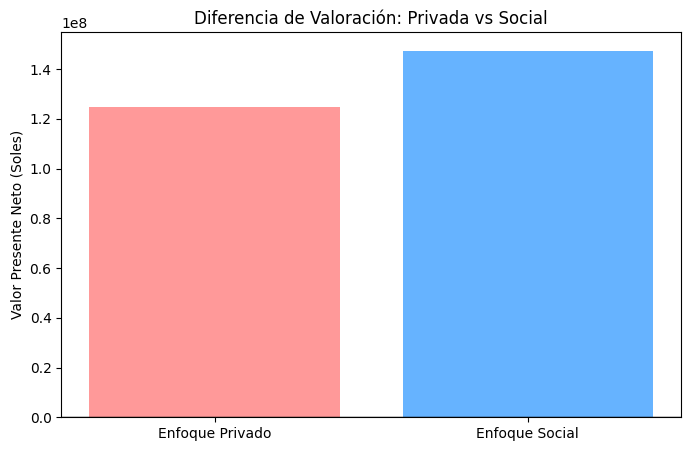

In [5]:
# 4. COMPARATIVA DE VALORACIÓN (VPN Privado vs VPN Social)

# Configuración del tipo de cálculo
modelo_detallado = True  # Cambiar a False para el cálculo simplificado

anios = np.arange(0, n_anios + 1)

if not modelo_detallado:
    # --- ENFOQUE SIMPLIFICADO ---
    # Cálculo rápido: asume que el flujo social es una proporción directa del privado
    flujo_caja_privado = np.full(n_anios + 1, recaudacion_total)
    flujo_caja_privado[0] = -inversion_total

    beneficio_social_factor = 1.15
    flujo_caja_social = flujo_caja_privado * beneficio_social_factor
    flujo_caja_social[0] = -inversion_total 
    
    print("Ejecutando: Modelo Simplificado")

else:
    # --- ENFOQUE COMPLETO (DESAGREGADO) ---
    # Basado en la fórmula: VPN_social = Σ (B_social - C_social) / (1 + r)^t
    
    # 1. Enfoque Privado
    flujo_caja_privado = np.full(n_anios + 1, recaudacion_total)
    flujo_caja_privado[0] = -inversion_total

    # 2. Enfoque Social Desagregado
    costos_sociales = np.full(n_anios + 1, 0.0)
    costos_sociales[0] = inversion_total  # CAPEX en t=0
    # Si hubiera OPEX social distinto, se sumaría aquí para t > 0
    costos_sociales[1:] = inversion_total * costo_om_pct 

    beneficios_sociales = np.full(n_anios + 1, recaudacion_total * 1.15)
    beneficios_sociales[0] = 0  # No hay beneficios en construcción
    
    # Flujo Neto Social (B - C)
    flujo_caja_social = beneficios_sociales - costos_sociales
    
    print("Ejecutando: Modelo Completo (Desagregado)")
    
def vpn(flujos, tasa):
    return sum(f / (1 + tasa)**t for t, f in enumerate(flujos))

vpn_p = vpn(flujo_caja_privado, tasa_interes_prestamo)
vpn_s = vpn(flujo_caja_social, tasa_social_descuento)

print(f"VPN Privado: S/ {vpn_p:,.2f}")
print(f"VPN Social: S/ {vpn_s:,.2f}")

# Visualización de la diferencia
labels = ['Enfoque Privado', 'Enfoque Social']
valores = [vpn_p, vpn_s]
plt.figure(figsize=(8, 5))
plt.bar(labels, valores, color=['#ff9999','#66b3ff'])
plt.axhline(0, color='black', linewidth=1)
plt.title('Diferencia de Valoración: Privada vs Social')
plt.ylabel('Valor Presente Neto (Soles)')
plt.show()

In [6]:
def generar_calendario_pagos(inversion, tasa, n_periodos, anio_inicio=2026):
    """
    Genera un cuadro de amortización bajo el sistema francés (cuota fija).
    """
    # 1. Calcular la cuota fija (Anualidad)
    if tasa > 0:
        cuota = inversion * (tasa * (1 + tasa)**n_periodos) / ((1 + tasa)**n_periodos - 1)
    else:
        cuota = inversion / n_periodos

    saldo = inversion
    datos = []
    interes_total = 0

    # 2. Ciclo de amortización
    for i in range(1, n_periodos + 1):
        interes = saldo * tasa
        amortizacion = cuota - interes
        saldo -= amortizacion
        
        interes_total += interes
        
        datos.append({
            "Año": anio_inicio + i - 1,
            "Cuota Anual (S/)": cuota,
            "Interés Pagado (S/)": interes,
            "Capital Amortizado (S/)": amortizacion,
            "Saldo Restante (S/)": max(saldo, 0) # Limpieza de decimales
        })

    # 3. Crear DataFrame
    df_pagos = pd.DataFrame(datos)
    
    return df_pagos, interes_total

In [7]:
# 1. Calculas la deuda (Calendario)
tabla_pagos, total_interes = generar_calendario_pagos(inversion_total, tasa_interes_prestamo, n_anios)

# 2. Tomas la cuota de la tabla para definir la recaudación
cuota_financiera = tabla_pagos.iloc[0]["Cuota Anual (S/)"]
recaudacion_total = cuota_financiera + opex_anual  # Lo que necesitas cobrar

In [14]:
total_interes

302425871.9069135

In [8]:
tabla_pagos

,Año,Cuota Anual (S/),Interés Pagado (S/),Capital Amortizado (S/),Saldo Restante (S/)
0,2026,4.012129e+07,2.500000e+07,1.512129e+07,4.848787e+08
1,2027,4.012129e+07,2.424394e+07,1.587736e+07,4.690013e+08
2,2028,4.012129e+07,2.345007e+07,1.667123e+07,4.523301e+08
3,2029,4.012129e+07,2.261651e+07,1.750479e+07,4.348253e+08
4,2030,4.012129e+07,2.174127e+07,1.838003e+07,4.164453e+08
5,2031,4.012129e+07,2.082227e+07,1.929903e+07,3.971463e+08
6,2032,4.012129e+07,1.985731e+07,2.026398e+07,3.768823e+08
7,2033,4.012129e+07,1.884411e+07,2.127718e+07,3.556051e+08
8,2034,4.012129e+07,1.778026e+07,2.234104e+07,3.332641e+08
9,2035,4.012129e+07,1.666320e+07,2.345809e+07,3.098060e+08


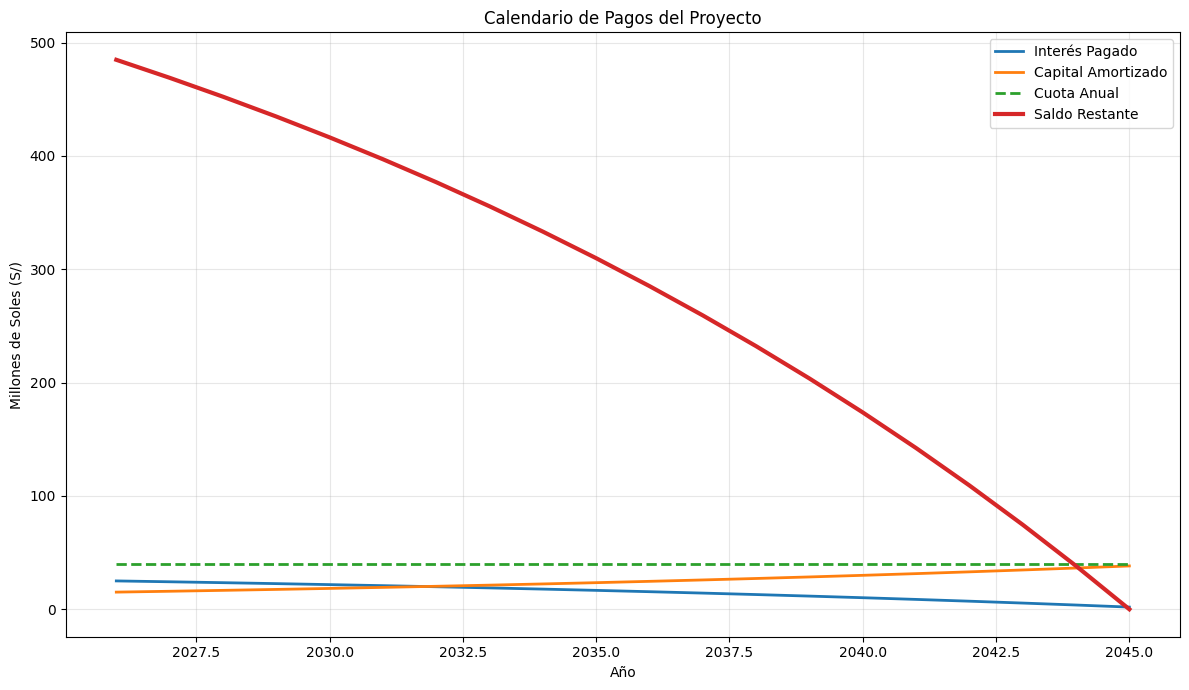

In [13]:
# ================================
# FUNCIÓN PARA GRAFICAR EL CALENDARIO
# ================================

def graficar_calendario_pagos(tabla_pagos):
    plt.figure(figsize=(12, 7))
    
    anios = tabla_pagos["Año"]
    
    plt.plot(anios, tabla_pagos["Interés Pagado (S/)"] / 1e6, 
             label="Interés Pagado", linewidth=2)
    
    plt.plot(anios, tabla_pagos["Capital Amortizado (S/)"] / 1e6, 
             label="Capital Amortizado", linewidth=2)
    
    plt.plot(anios, tabla_pagos["Cuota Anual (S/)"] / 1e6, 
             label="Cuota Anual", linestyle="--", linewidth=2)
    
    plt.plot(anios, tabla_pagos["Saldo Restante (S/)"] / 1e6, 
             label="Saldo Restante", linewidth=3)
    
    plt.title("Calendario de Pagos del Proyecto")
    plt.xlabel("Año")
    plt.ylabel("Millones de Soles (S/)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Llamar la función
graficar_calendario_pagos(tabla_pagos)